# MNIST Dataset

In [1]:
import numpy as np
import struct
import matplotlib.pyplot as plt
from collections import Counter

%matplotlib inline

## Load data

In [3]:
def read_idx_images(filename):
    with open(filename, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, rows, cols)
    return images

def read_idx_labels(filename):
    with open(filename, 'rb') as f:
        magic, num_labels = struct.unpack('>II', f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
    return labels

train_images = read_idx_images('../data/train-images.idx3-ubyte')
train_labels = read_idx_labels('../data/train-labels.idx1-ubyte')
test_images = read_idx_images('../data/t10k-images.idx3-ubyte')
test_labels = read_idx_labels('../data/t10k-labels.idx1-ubyte')

In [4]:
print(f"Training: {train_images.shape}")
print(f"Test: {test_images.shape}")
print(f"Image size: {train_images.shape[1]}x{train_images.shape[2]}")
print(f"Pixel range: {train_images.min()} - {train_images.max()}")

Training: (60000, 28, 28)
Test: (10000, 28, 28)
Image size: 28x28
Pixel range: 0 - 255


## Sample images

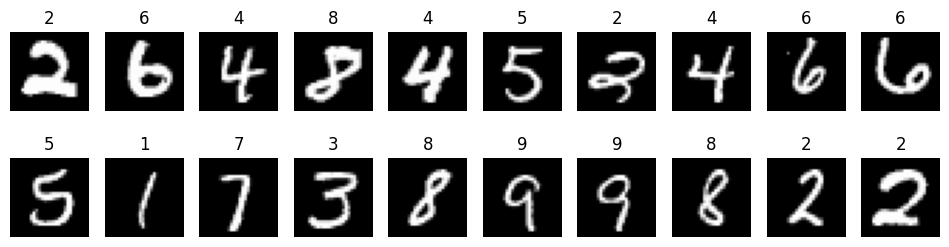

In [5]:
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    idx = np.random.randint(len(train_images))
    ax.imshow(train_images[idx], cmap='gray')
    ax.set_title(train_labels[idx])
    ax.axis('off')
plt.show()

## Class distribution

In [6]:
counts = Counter(train_labels)
for digit in range(10):
    print(f"Digit {digit}: {counts[digit]}")

Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949


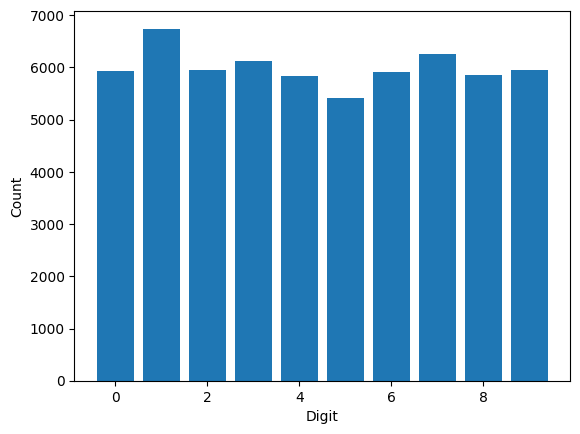

In [7]:
plt.bar(range(10), [counts[i] for i in range(10)])
plt.xlabel('Digit')
plt.ylabel('Count')
plt.show()

## Average digit

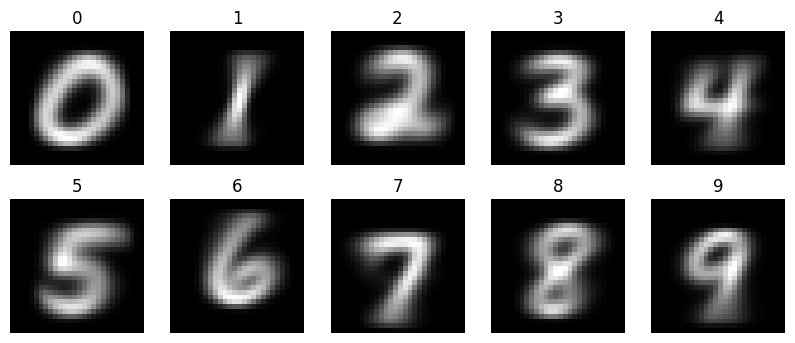

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    mask = train_labels == digit
    avg = train_images[mask].mean(axis=0)
    ax.imshow(avg, cmap='gray')
    ax.set_title(f'{digit}')
    ax.axis('off')
plt.show()